# Análisis de Proyecto Integrador de Aprendizaje Automatizado

In [256]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [257]:
dataset = pd.read_csv('data.csv', sep=';')

In [258]:
print("Dimensiones:", dataset.shape)

Dimensiones: (4424, 37)


In [259]:
dataset.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [260]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [261]:
dataset.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [262]:
dataset.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [263]:
dataset.Target.value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


Distribución de variables numéricas:


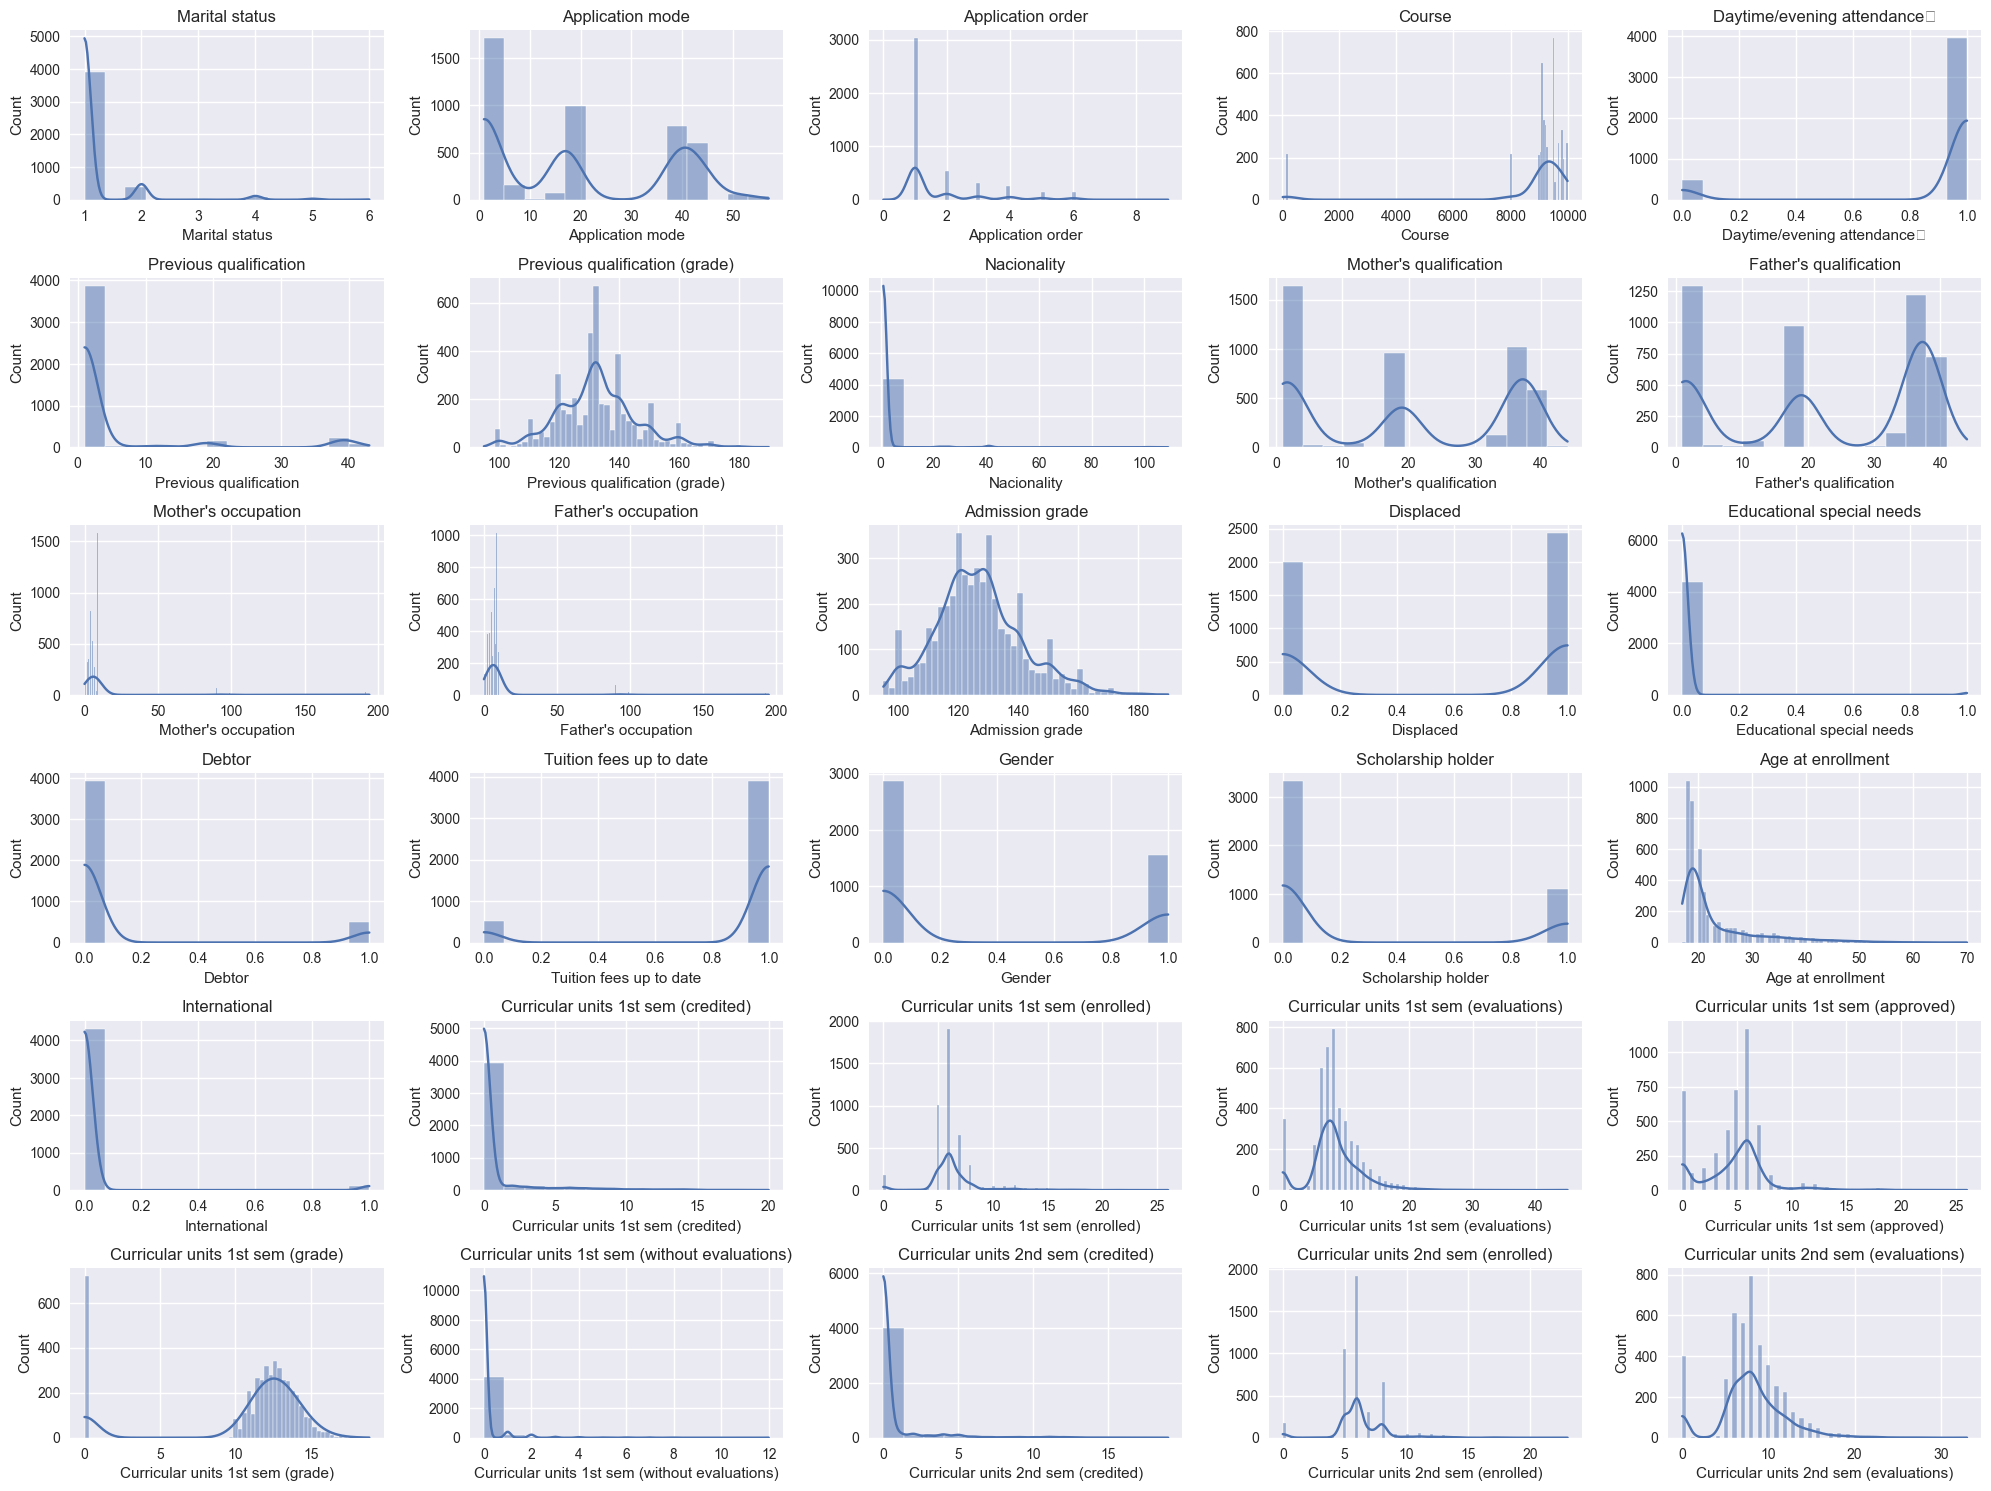

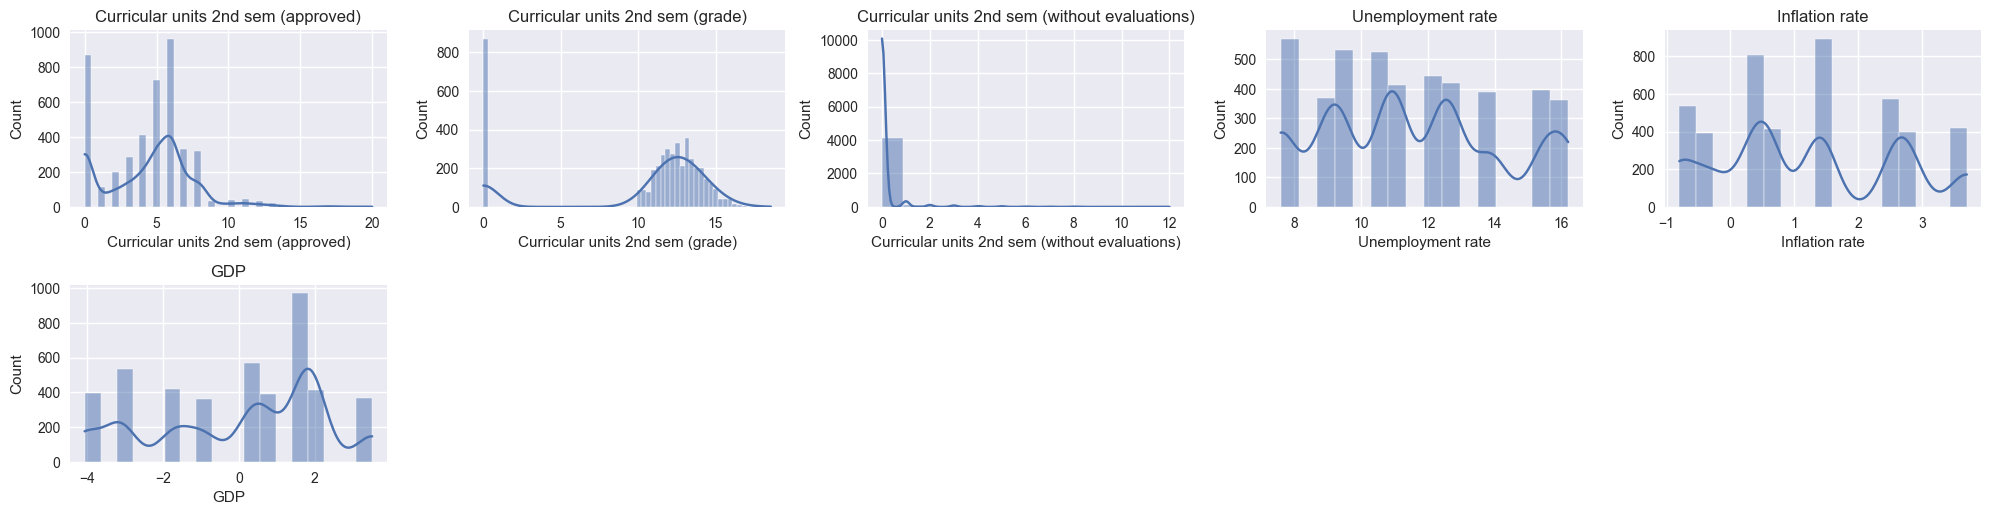

In [264]:
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns.tolist() 
print("\nDistribución de variables numéricas:")
chunk_size = 30
for j in range(0, len(numeric_cols), chunk_size):
    plt.figure(figsize=(20, 15))
    for i, col in enumerate(numeric_cols[j:j+chunk_size]):
        plt.subplot(6, 5, i+1)
        sns.histplot(dataset[col], kde=True)
        plt.title(col)
    plt.tight_layout()
    plt.show()

Número de columnas numéricas: 36
Columnas numéricas: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment 

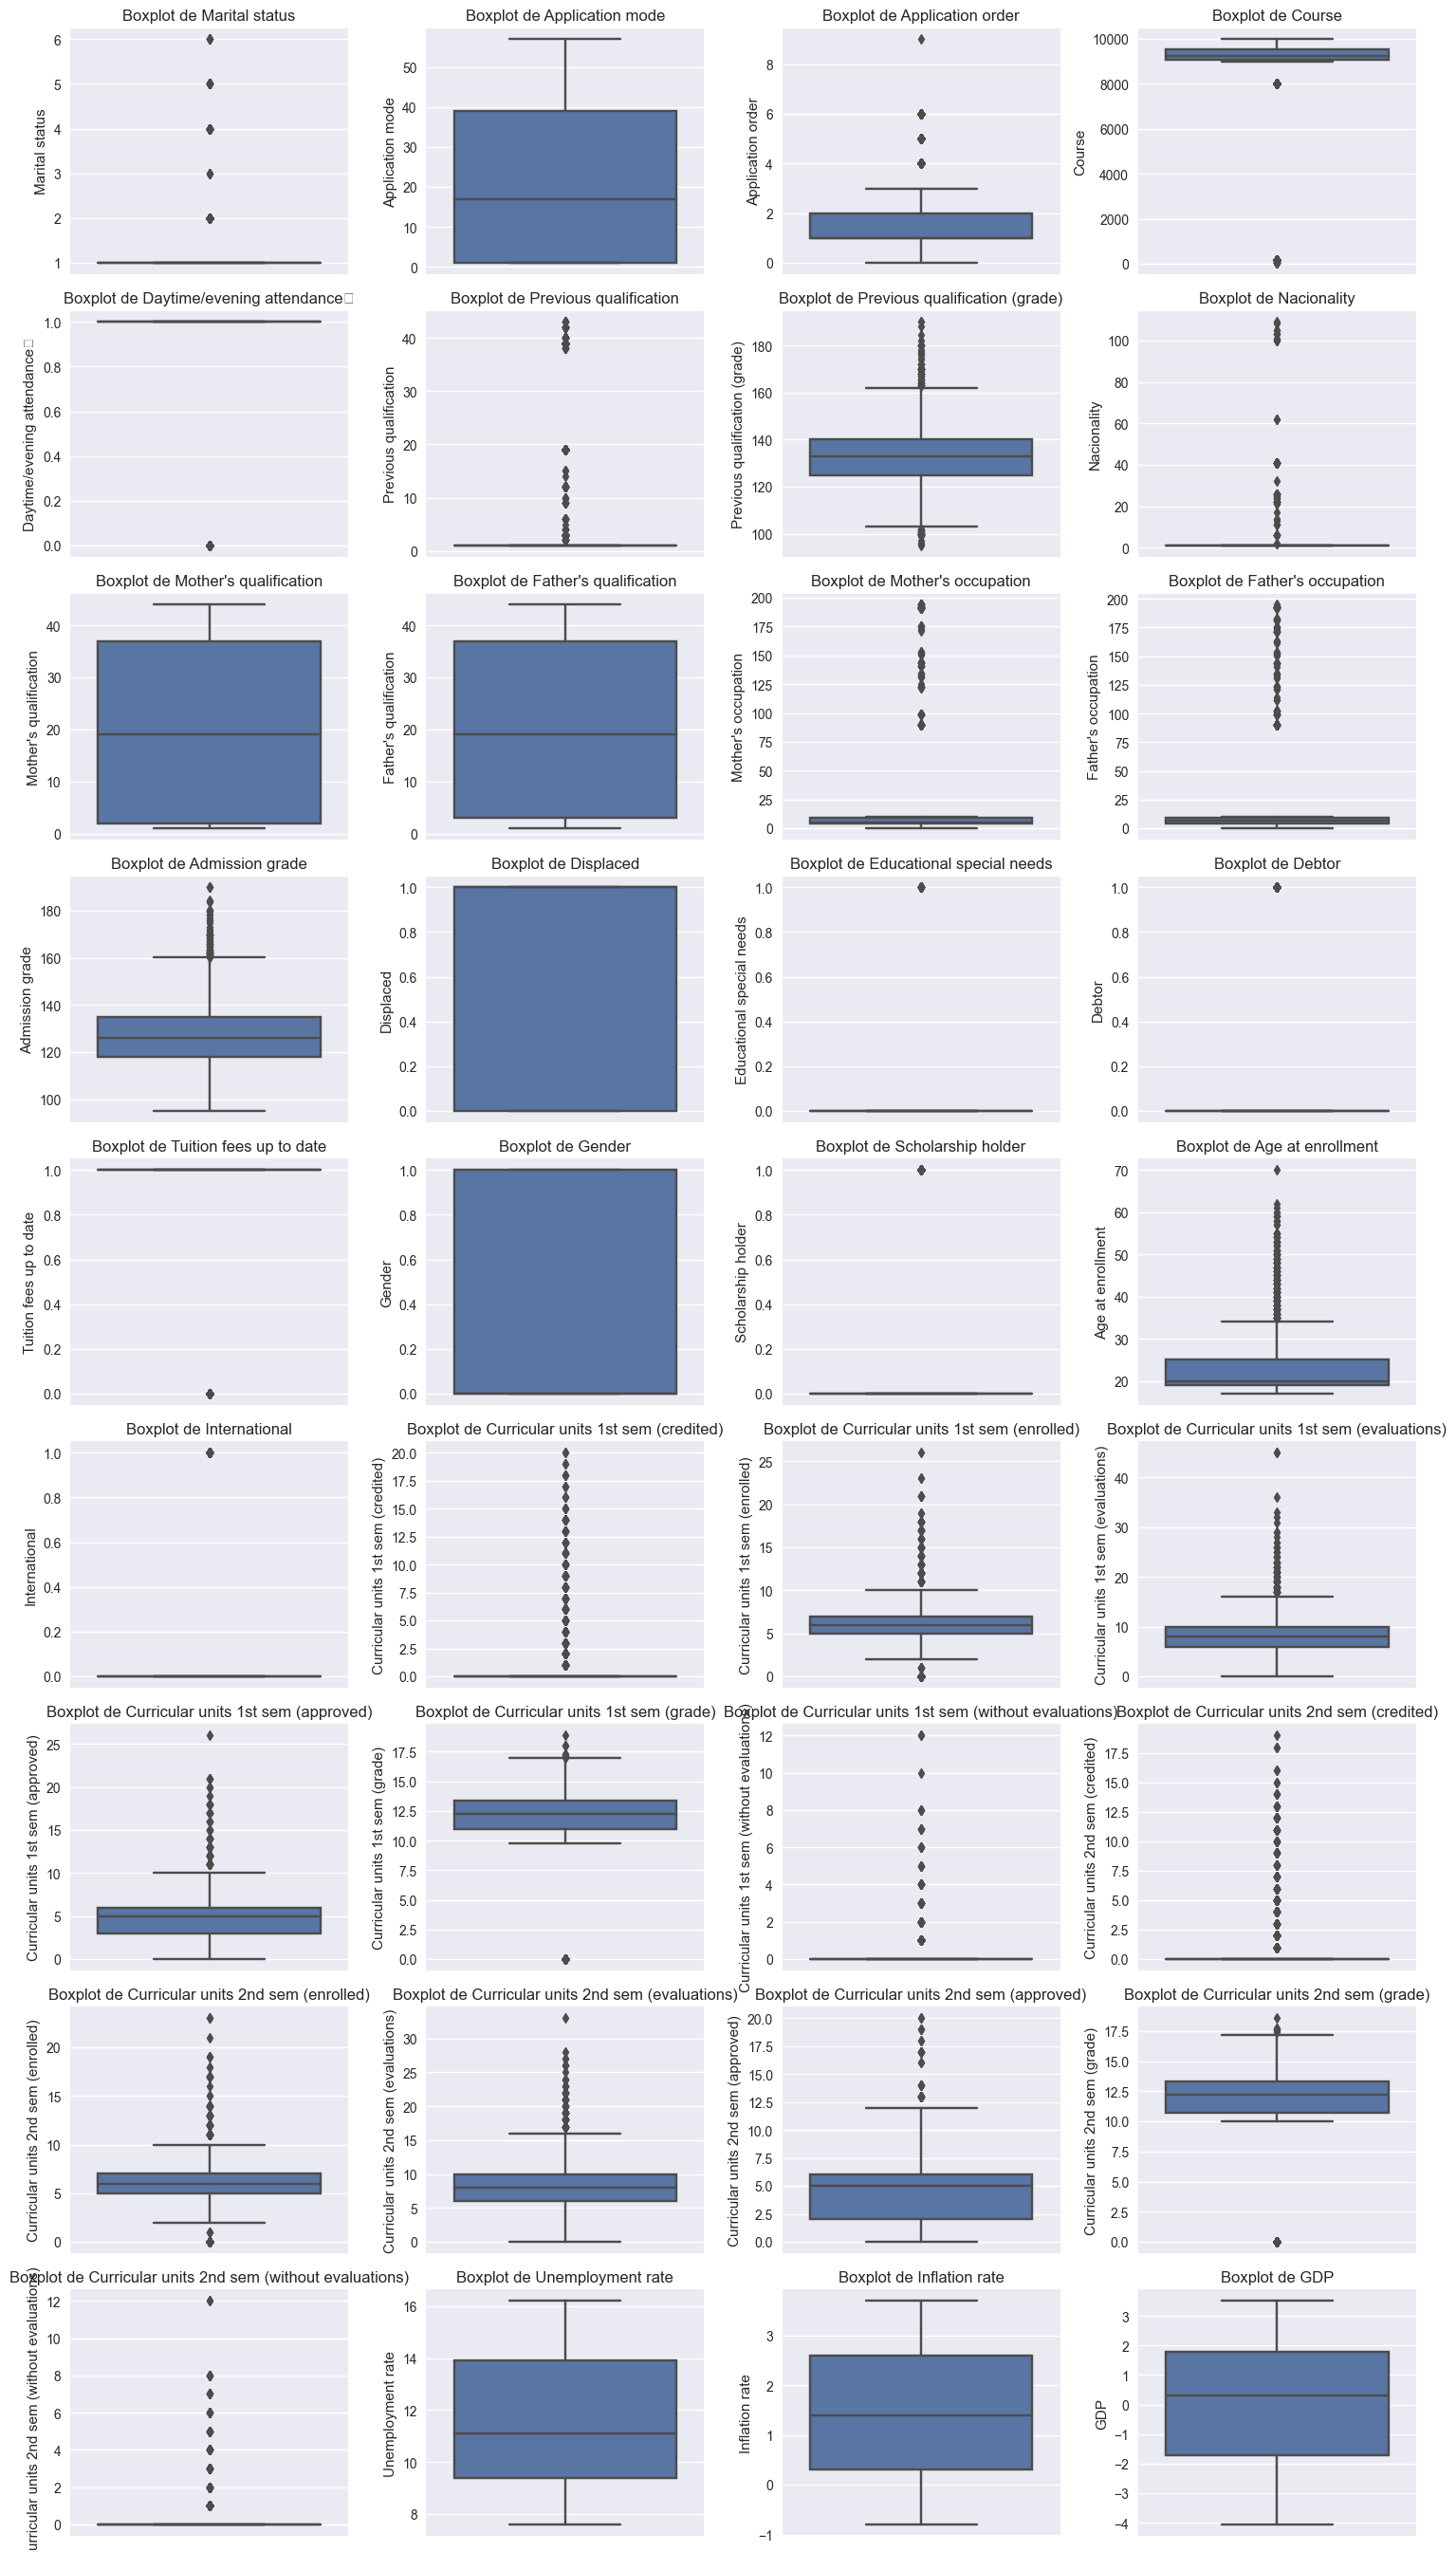

In [265]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

def plot_outliers(dataset, columns):
    n_cols = len(columns)
    n_rows = (n_cols + 3) // 4  
    plt.figure(figsize=(15, 3 * n_rows))
    
    for i, col in enumerate(columns):
        plt.subplot(n_rows, 4, i+1)
        sns.boxplot(y=dataset[col])
        plt.title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
print(f"Número de columnas numéricas: {len(numeric_cols)}")
print("Columnas numéricas:", list(numeric_cols))
plot_outliers(dataset, numeric_cols)

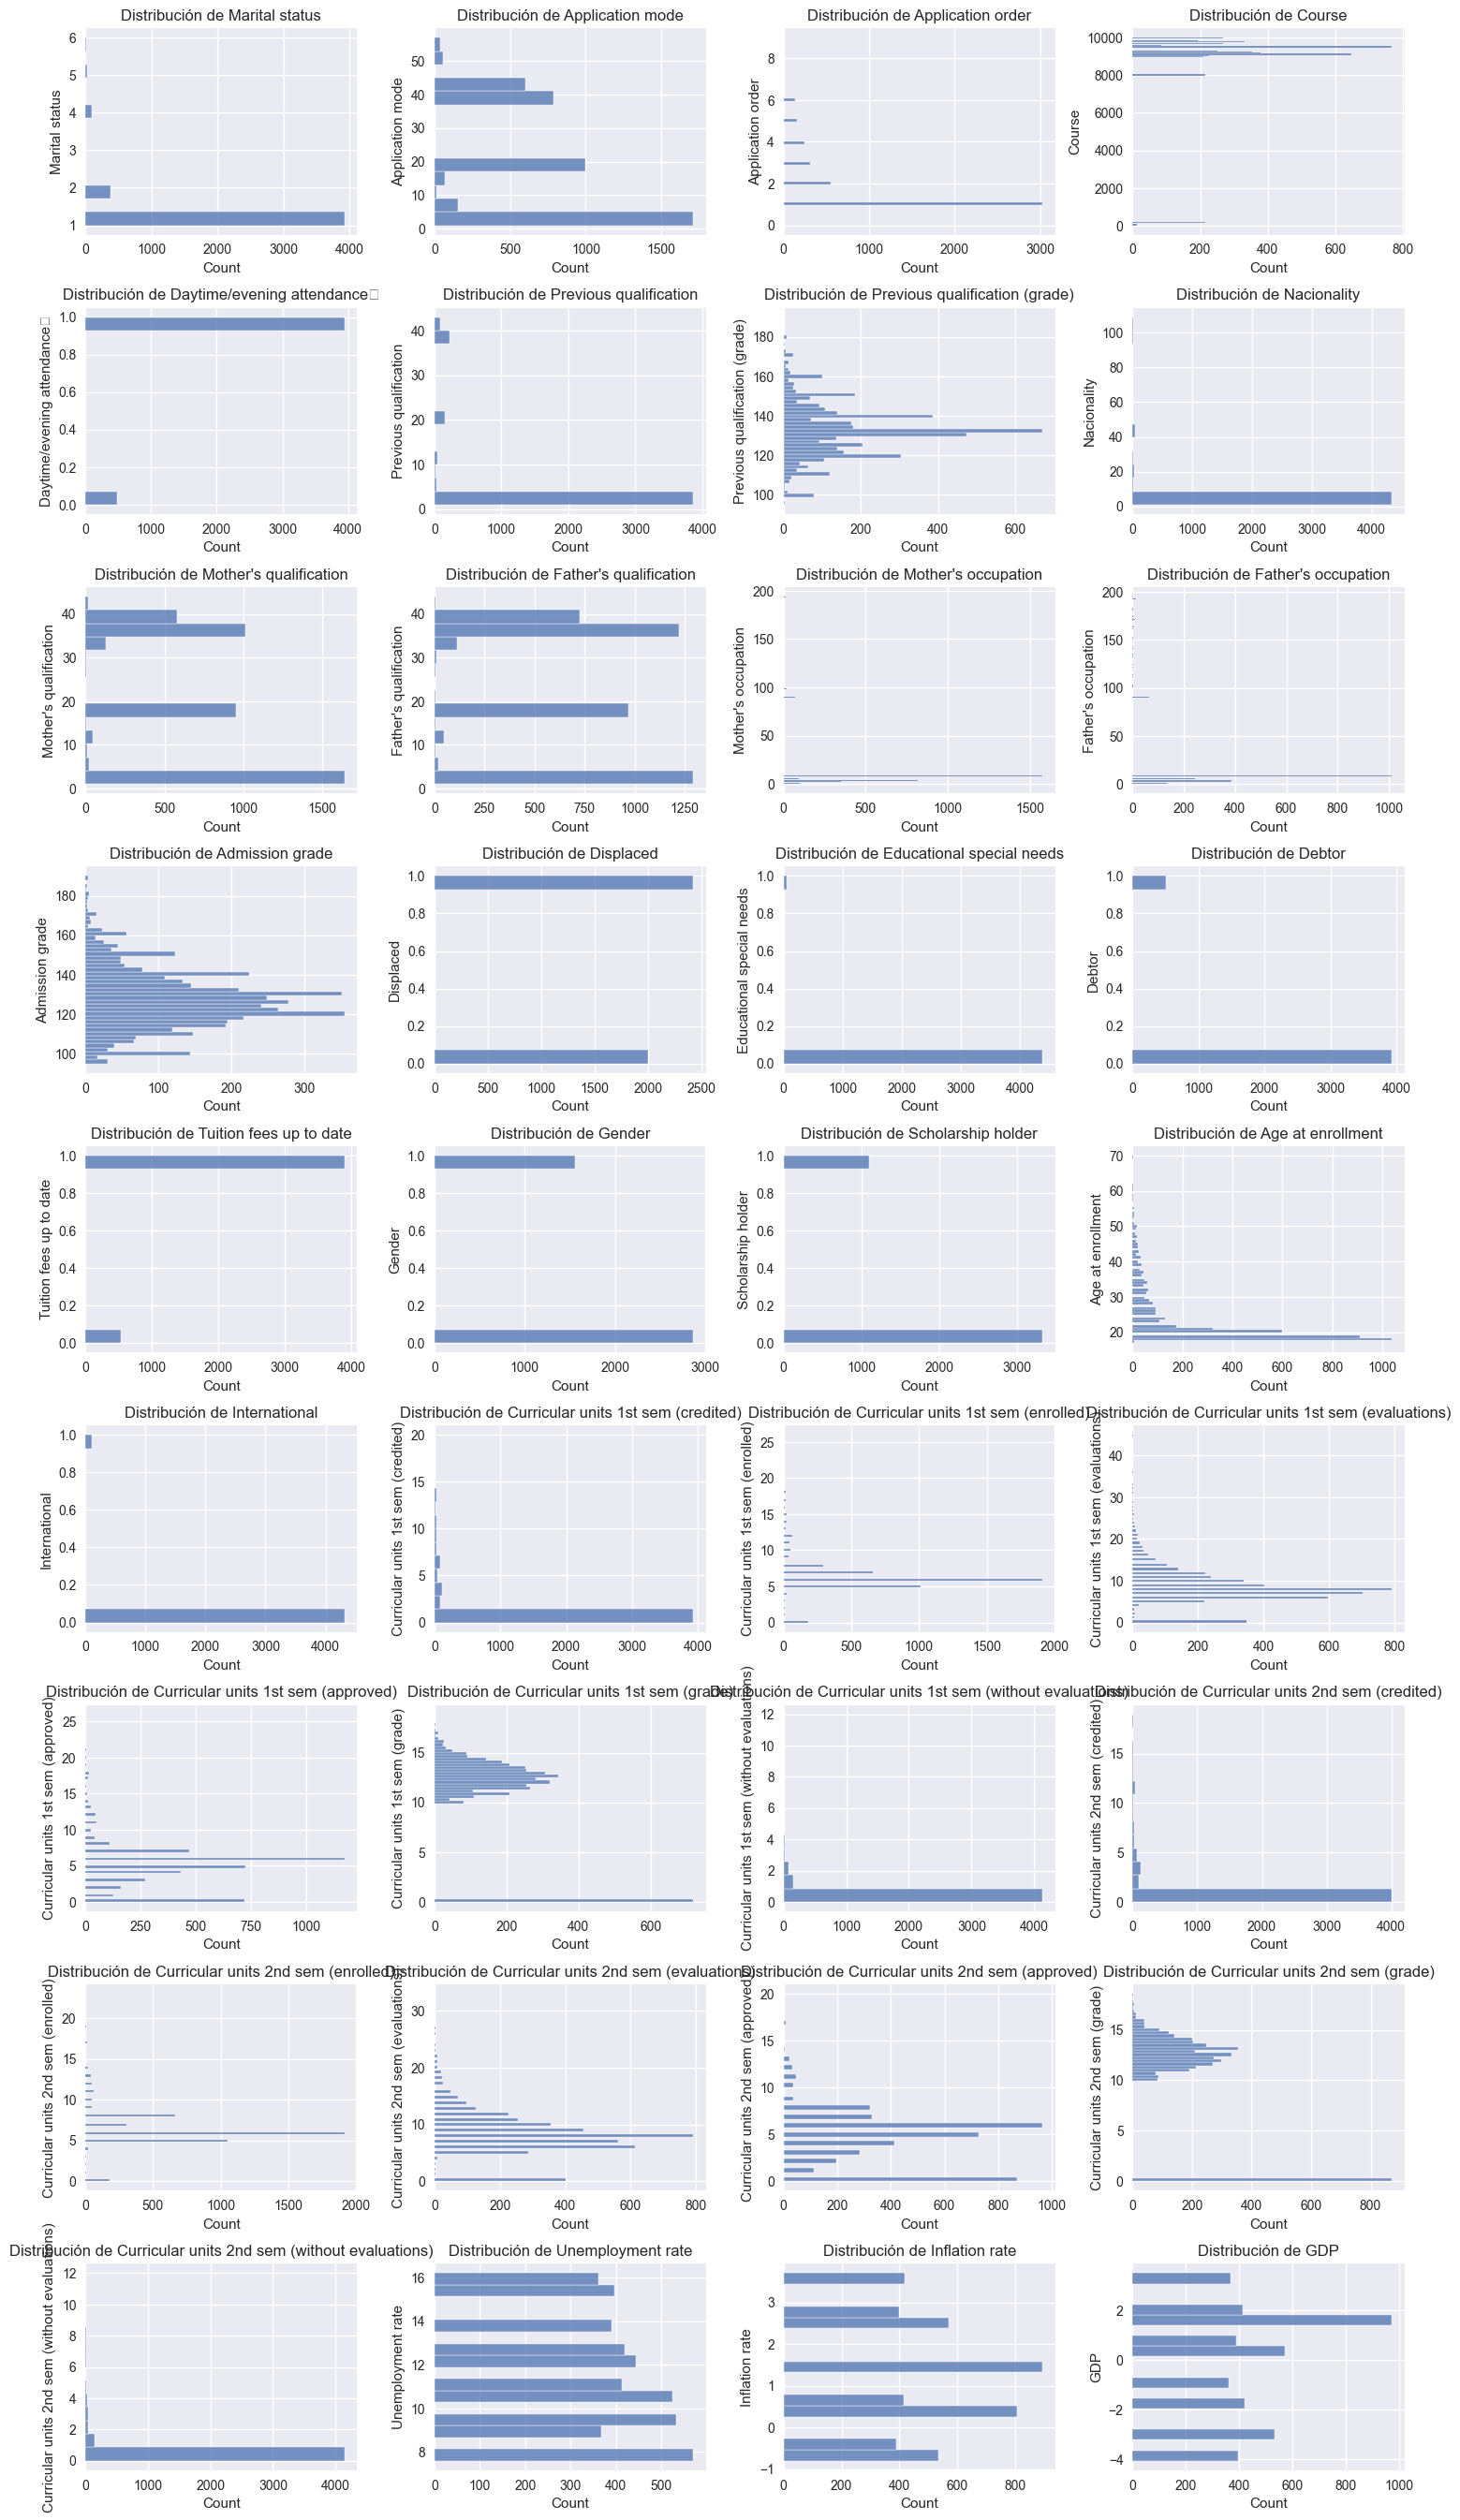

In [266]:
def plot_distributions(dataset, columns):
    n_cols = len(columns)
    n_rows = (n_cols + 3) // 4  
    plt.figure(figsize=(15, 3 * n_rows))
    for i, col in enumerate(columns):
        plt.subplot(n_rows, 4, i+1)
        sns.histplot(y=dataset[col])
        plt.title(f'Distribución de {col}')
        plt.tight_layout()
    plt.show()
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
plot_distributions(dataset, numeric_cols)

Matriz de correlación: (36, 36)


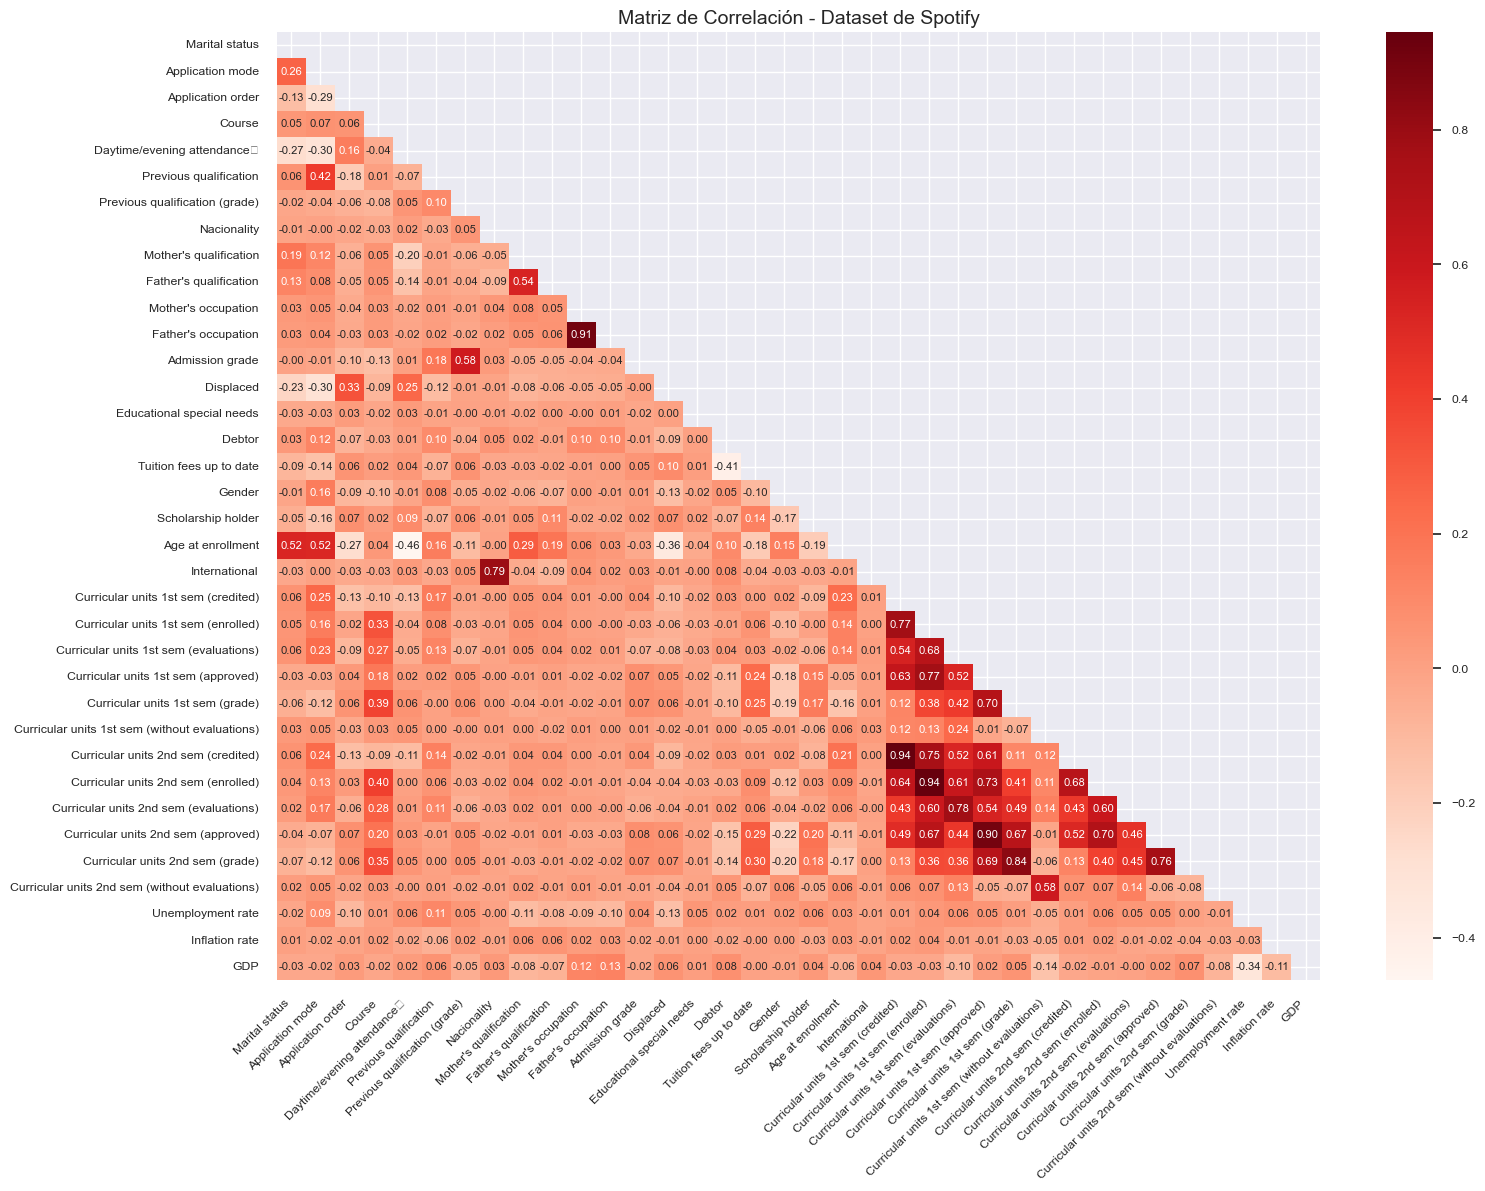

In [267]:
dataset_num = dataset.select_dtypes(include=np.number)
corr = dataset_num.corr()
print("Matriz de correlación:", corr.shape)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
plt.figure(figsize=(16, 12))  
sns.set(font_scale=0.8)       
sns.heatmap(
    corr, 
    mask=mask, 
    cmap='Reds', 
    annot=True, 
    fmt='.2f', 
    annot_kws={"size": 8},   
    cbar=True
)
plt.xticks(rotation=45, ha="right")  
plt.yticks(rotation=0)               
plt.title("Matriz de Correlación - Dataset de Spotify", fontsize=14)
plt.tight_layout()
plt.show()

In [268]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from IPython.display import display
def VIF_calculation(X):
    VIF = pd.DataFrame()
    VIF["variable"] = X.columns
    VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    VIF = VIF.sort_values('VIF', ascending=False).reset_index(drop=True)
    return VIF
def delete_multicollinearity(df, target_name, VIF_threshold=10):
    X = df.drop(columns=[target_name])

    X = X.select_dtypes(include=[np.number])
    
    VIF_mat = VIF_calculation(X)
    n_VIF = VIF_mat["VIF"][0]

    if n_VIF <= VIF_threshold:
        print(" No hay multicolinealidad.")
    else:
        print(" Se detectó multicolinealidad. Eliminando variables...")
        while n_VIF > VIF_threshold:
            print(f"Eliminando '{VIF_mat['variable'][0]}' con VIF={n_VIF:.2f}")
            X = X.drop(columns=[VIF_mat["variable"][0]])
            VIF_mat = VIF_calculation(X)
            n_VIF = VIF_mat["VIF"][0]

    display(VIF_mat)
    return pd.concat([X, df[[target_name]]], axis=1)
df_copy = delete_multicollinearity(dataset, "Target", 10)

 Se detectó multicolinealidad. Eliminando variables...
Eliminando 'Curricular units 1st sem (enrolled)' con VIF=180.79
Eliminando 'Previous qualification (grade)' con VIF=129.64
Eliminando 'Curricular units 2nd sem (enrolled)' con VIF=50.74
Eliminando 'Admission grade' con VIF=43.84
Eliminando 'Curricular units 1st sem (approved)' con VIF=36.97
Eliminando 'Curricular units 2nd sem (grade)' con VIF=25.24
Eliminando 'Course' con VIF=23.20
Eliminando 'Unemployment rate' con VIF=18.77
Eliminando 'Curricular units 1st sem (evaluations)' con VIF=16.33
Eliminando 'Age at enrollment' con VIF=16.11
Eliminando 'Curricular units 1st sem (grade)' con VIF=14.75
Eliminando 'Curricular units 2nd sem (credited)' con VIF=10.60


,variable,VIF
0,Tuition fees up to date,8.699219
1,Daytime/evening attendance\t,8.115330
2,Curricular units 2nd sem (evaluations),7.362941
3,Father's occupation,7.070751
4,Mother's occupation,6.973680
5,Curricular units 2nd sem (approved),6.278566
6,Marital status,4.714827
7,Father's qualification,4.364045
8,Mother's qualification,3.759655
9,Application mode,3.243779


In [269]:
dataset_num = dataset.select_dtypes(include=np.number)
dataset_num = dataset_num.dropna(axis=1)  
scaler = StandardScaler()
spotify_scaled = scaler.fit_transform(dataset_num)

vif_data = pd.DataFrame()
vif_data["Variable"] = dataset_num.columns
vif_data["VIF"] = [variance_inflation_factor(spotify_scaled, i) for i in range(spotify_scaled.shape[1])]
print(vif_data.sort_values(by="VIF", ascending=False))

                                          Variable        VIF
22             Curricular units 1st sem (enrolled)  24.482511
28             Curricular units 2nd sem (enrolled)  17.207212
21             Curricular units 1st sem (credited)  16.223547
24             Curricular units 1st sem (approved)  13.103872
27             Curricular units 2nd sem (credited)  12.591785
30             Curricular units 2nd sem (approved)  10.736544
10                             Mother's occupation   5.979421
11                             Father's occupation   5.970843
31                Curricular units 2nd sem (grade)   5.778227
25                Curricular units 1st sem (grade)   5.197275
23          Curricular units 1st sem (evaluations)   4.014065
29          Curricular units 2nd sem (evaluations)   3.386472
20                                   International   2.713637
7                                      Nacionality   2.694558
19                               Age at enrollment   2.301982
3       

Distribución de la variable target:
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


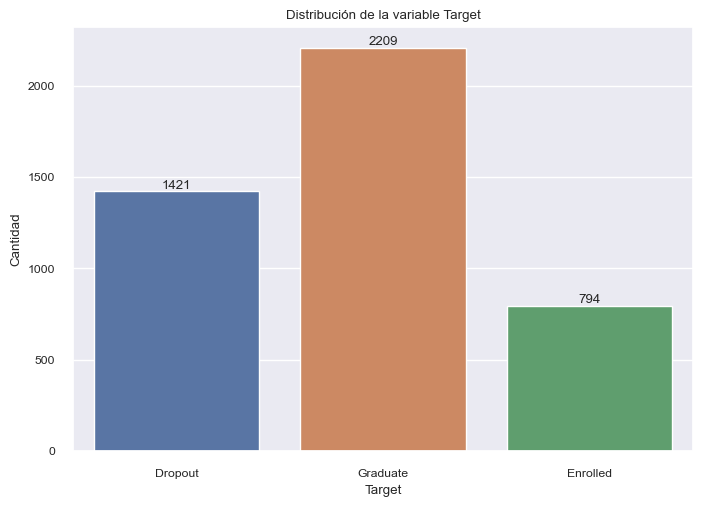

In [270]:
print("Distribución de la variable target:")
print(dataset['Target'].value_counts(normalize=True)*100)
ax = sns.countplot(x='Target', data=dataset)
plt.title('Distribución de la variable Target')
plt.xlabel('Target')
plt.ylabel('Cantidad')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')
plt.show()

In [271]:
from sklearn.preprocessing import RobustScaler
print("Escalado de características")
scaler = RobustScaler()
df_scaled = dataset.copy()
df_scaled[numeric_cols] = scaler.fit_transform(dataset[numeric_cols])
print("\nEstadísticas después de escalado (RobustScaler):")
print(df_scaled[numeric_cols].describe().T)

Escalado de características

Estadísticas después de escalado (RobustScaler):
                                                 count      mean        std  \
Marital status                                  4424.0  0.178571   0.605747   
Application mode                                4424.0  0.043923   0.460123   
Application order                               4424.0  0.727848   1.313793   
Course                                          4424.0 -0.809676   4.381245   
Daytime/evening attendance\t                    4424.0 -0.109177   0.311897   
Previous qualification                          4424.0  3.577758  10.216592   
Previous qualification (grade)                  4424.0 -0.032446   0.879222   
Nacionality                                     4424.0  0.873192   6.914514   
Mother's qualification                          4424.0  0.016055   0.445805   
Father's qualification                          4424.0  0.096333   0.451268   
Mother's occupation                             4424.

In [272]:
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
target_encoded = dataset['Target'].astype('category').cat.codes

mi_scores = mutual_info_classif(dataset[numeric_cols], target_encoded, random_state=42)
mi_dataset = pd.DataFrame({'Variable': numeric_cols, 'MI_Score': mi_scores})
mi_dataset = mi_dataset.sort_values('MI_Score', ascending=False)

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(dataset[numeric_cols], target_encoded)
anova_df = pd.DataFrame({'Variable': numeric_cols, 'F_Score': selector.scores_})
anova_df = anova_df.sort_values('F_Score', ascending=False)

feature_importance = mi_dataset.merge(anova_df, on='Variable')
feature_importance['Combined_Score'] = (feature_importance['MI_Score'] + 
                                      feature_importance['F_Score']/feature_importance['F_Score'].max())
feature_importance = feature_importance.sort_values('Combined_Score', ascending=False)

print("\nVariables predictoras más importantes:")
print(feature_importance.head(15))


Variables predictoras más importantes:
                                  Variable  MI_Score      F_Score  \
0      Curricular units 2nd sem (approved)  0.310207  1410.732938   
1         Curricular units 2nd sem (grade)  0.239324  1134.109544   
2      Curricular units 1st sem (approved)  0.233439   859.866768   
3         Curricular units 1st sem (grade)  0.184882   713.517328   
4                  Tuition fees up to date  0.100460   505.621429   
14                      Scholarship holder  0.037139   225.751437   
7                        Age at enrollment  0.065516   154.712071   
5   Curricular units 2nd sem (evaluations)  0.096761    87.801092   
15                                  Debtor  0.033628   137.647527   
10                        Application mode  0.046571   114.534956   
18                                  Gender  0.024435   123.041811   
6   Curricular units 1st sem (evaluations)  0.075691    37.527840   
12     Curricular units 2nd sem (enrolled)  0.041576    75.5919


Top 10 variables predictoras identificadas:
['Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 2nd sem (evaluations)', 'Debtor', 'Application mode']


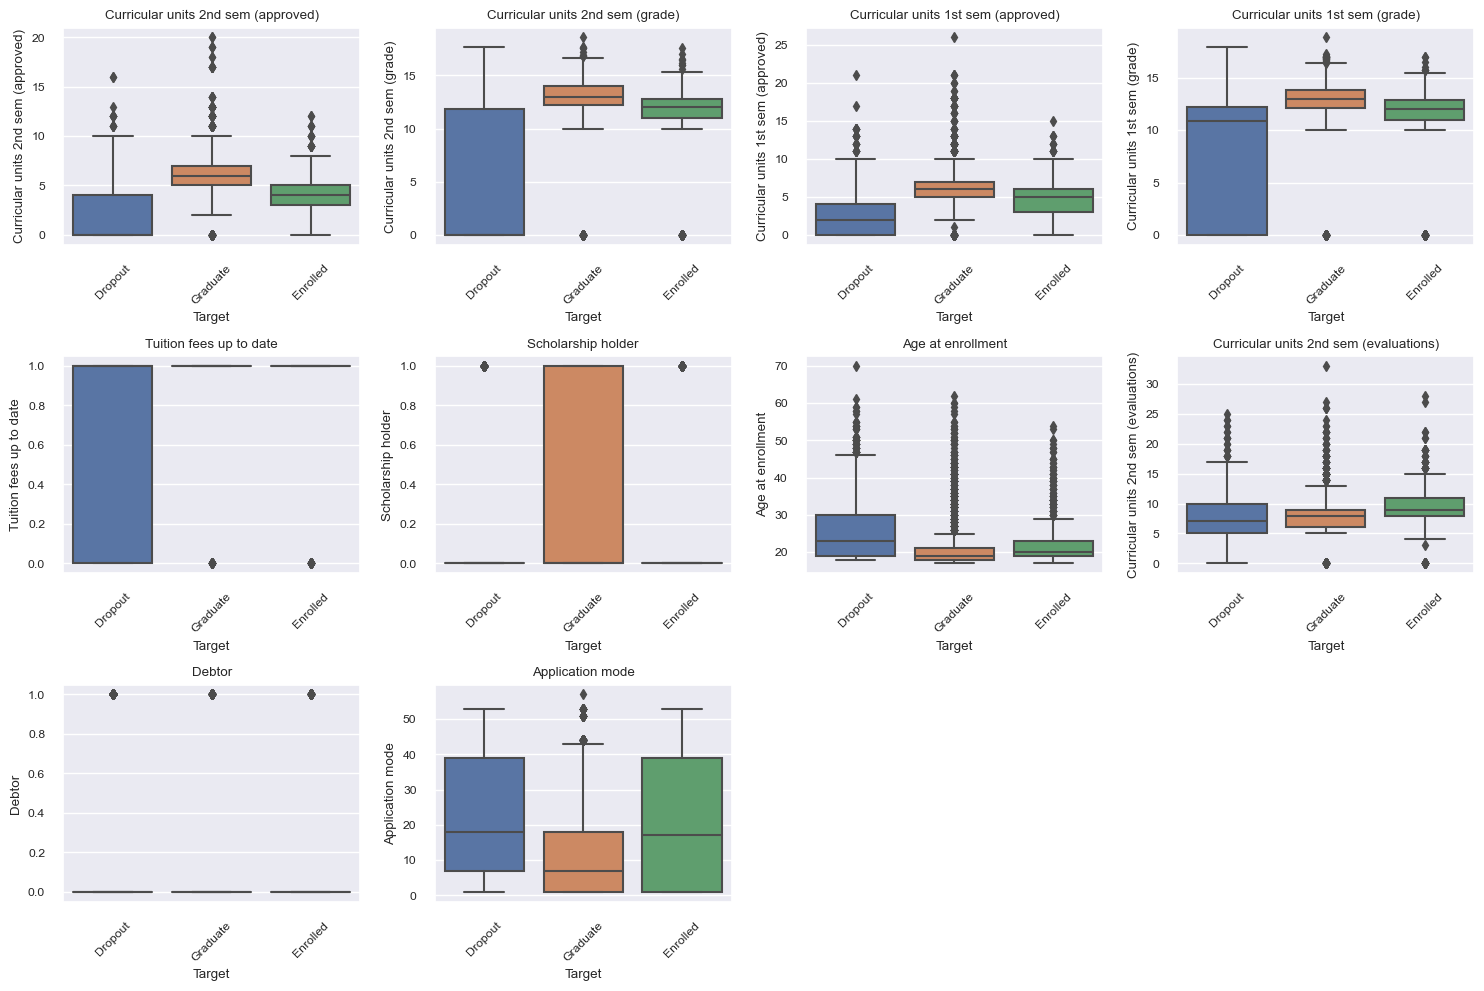

In [273]:
top_features = feature_importance['Variable'].head(10).tolist()
print("\nTop 10 variables predictoras identificadas:")
print(top_features)

plt.figure(figsize=(15, 10))
for i, col in enumerate(top_features):
    plt.subplot(3, 4, i+1)
    if col in numeric_cols:
        sns.boxplot(data=dataset, y=col, x='Target')
    else:
        sns.countplot(data=dataset, x=col, hue='Target')
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Análisis Bivariado Avanzado


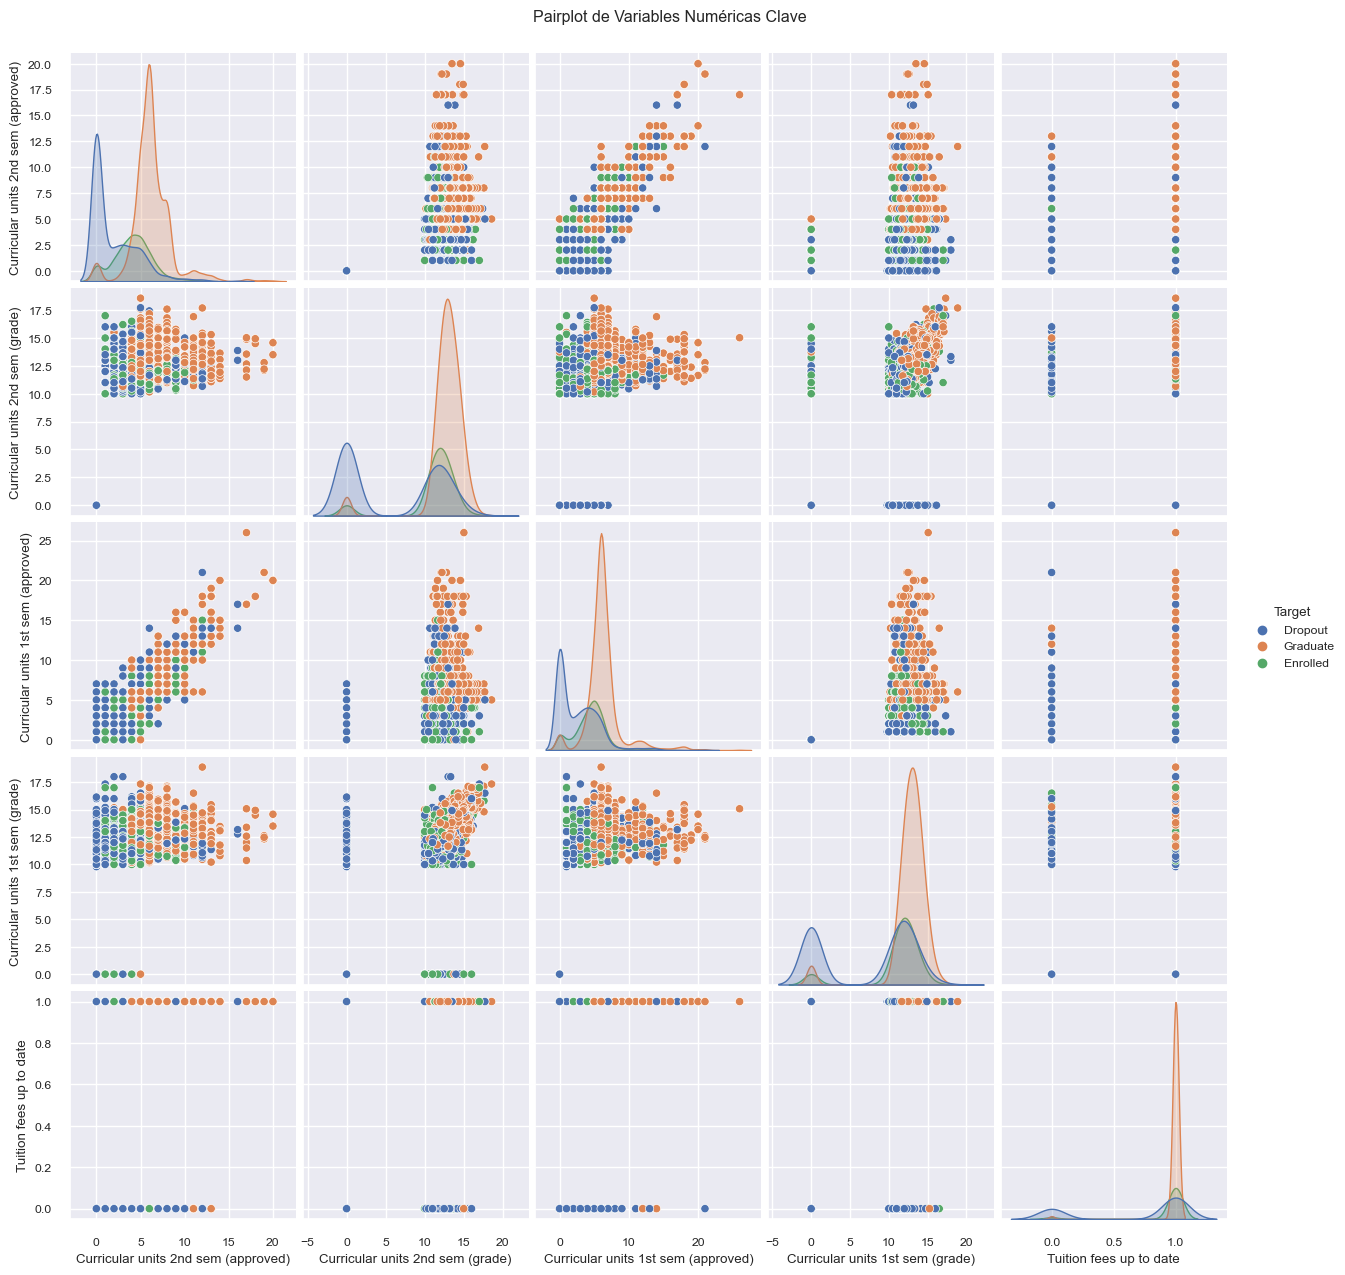

Correlación entre Variables Clave y Target (codificado)


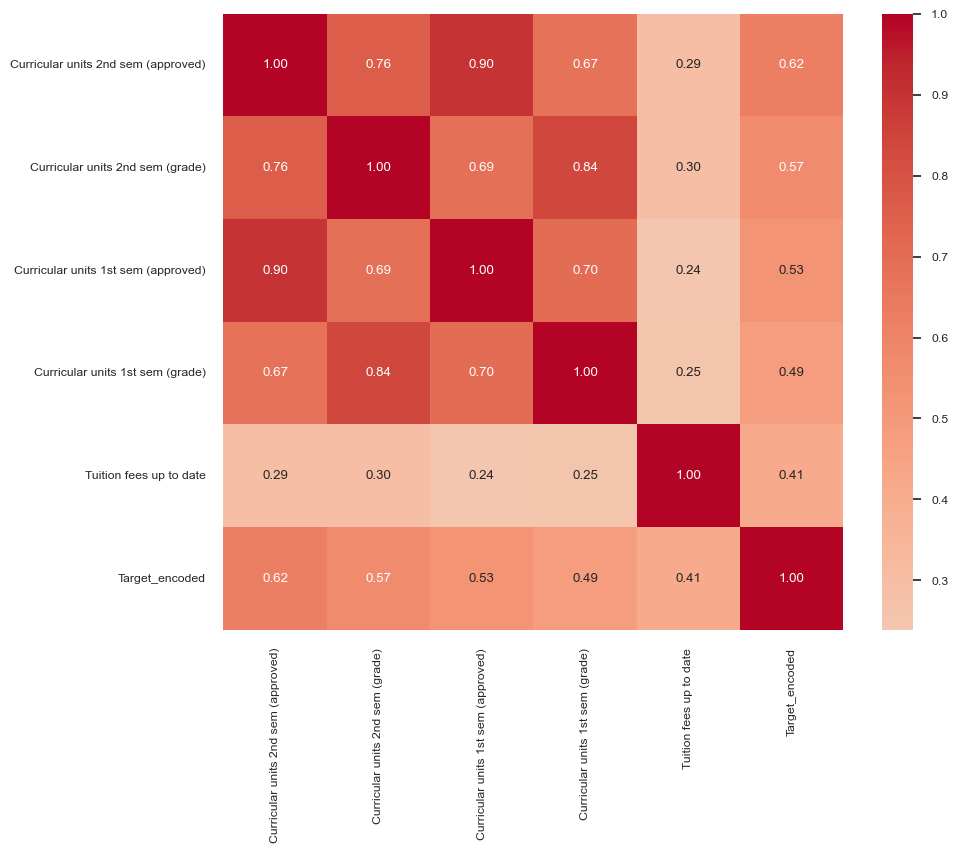

In [274]:
print("Análisis Bivariado Avanzado")
top_numeric = [f for f in top_features if f in numeric_cols][:5]

if top_numeric:
    sns.pairplot(data=dataset, vars=top_numeric, hue='Target')
    plt.suptitle('Pairplot de Variables Numéricas Clave', y=1.02)
    plt.show()

    print("Correlación entre Variables Clave y Target (codificado)")
    if 'Target' in dataset.select_dtypes(include=['number']).columns:
        corr_data = dataset[top_numeric + ['Target']]
    else:
        corr_data = dataset[top_numeric].join(target_encoded.rename('Target_encoded'))
    
    top_corr = corr_data.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(top_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.show()
else:
    print("No se encontraron variables numéricas entre las características seleccionadas.")


Mejor k encontrado: 8 con accuracy de validación cruzada: 0.8466

Accuracy en test: 0.8381024096385542

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.60      0.71       427
           1       0.83      0.95      0.89       901

    accuracy                           0.84      1328
   macro avg       0.84      0.78      0.80      1328
weighted avg       0.84      0.84      0.83      1328



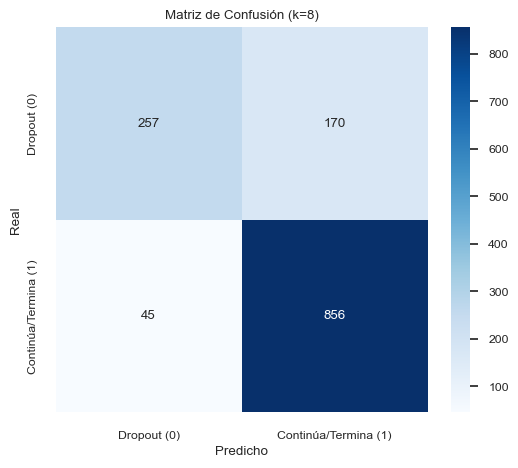

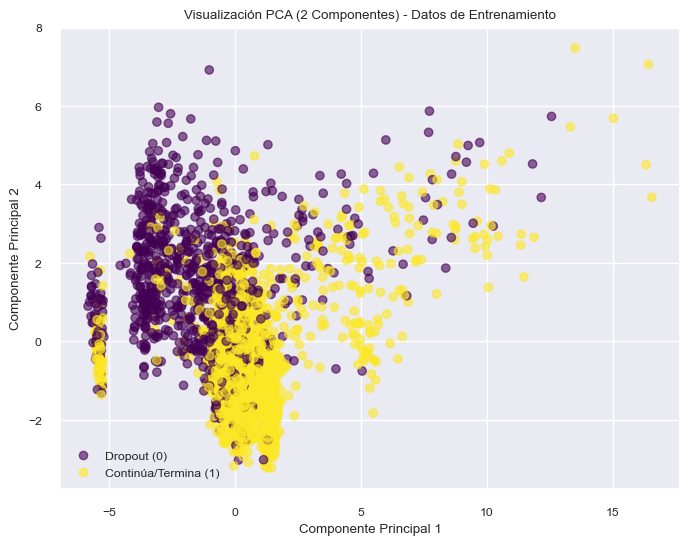

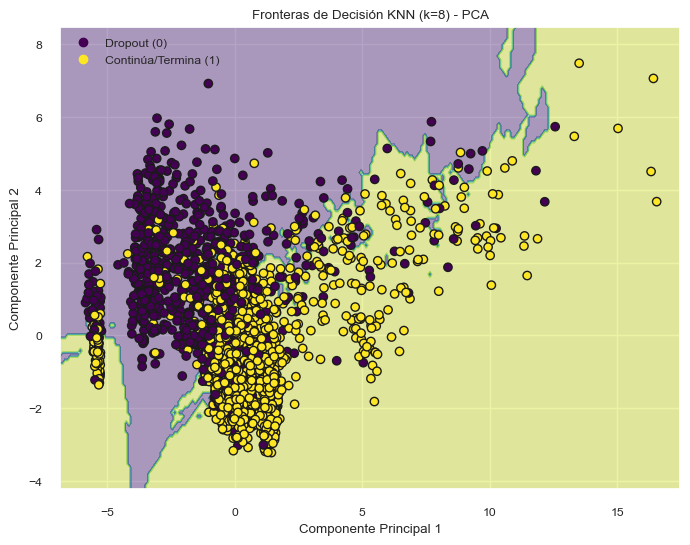

In [275]:
categorical_nominal = [
    'Marital status', 'Application mode', 'Course', 'Nacionality',
    "Mother's occupation", "Father's occupation"
]
for col in categorical_nominal:
    dataset[col] = dataset[col].astype(str)
dataset['Target_binary'] = dataset['Target'].apply(lambda x: 0 if x == 'Dropout' else 1)
X = dataset.drop(['Target', 'Target_binary'], axis=1)
y = dataset['Target_binary']
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_nominal)
    ],
    remainder='passthrough'  
)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])
best_score = 0
best_k = 1
cv_scores = []

for k in range(1, 20):
    pipeline.set_params(classifier__n_neighbors=k)
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = np.mean(scores)
    cv_scores.append(mean_score)
    if mean_score > best_score:
        best_score = mean_score
        best_k = k

print(f"\nMejor k encontrado: {best_k} con accuracy de validación cruzada: {best_score:.4f}")
pipeline.set_params(classifier__n_neighbors=best_k)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("\nAccuracy en test:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dropout (0)', 'Continúa/Termina (1)'], 
            yticklabels=['Dropout (0)', 'Continúa/Termina (1)'])
plt.title(f"Matriz de Confusión (k={best_k})")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()
X_train_processed = pipeline.named_steps['preprocessor'].transform(X_train)
X_train_processed = X_train_processed.toarray()  

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_processed)
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.6)
plt.title('Visualización PCA (2 Componentes) - Datos de Entrenamiento')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(handles=scatter.legend_elements()[0], 
           labels=['Dropout (0)', 'Continúa/Termina (1)'])
plt.show()
def plot_decision_boundaries(X_pca, y, k):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_pca, y)
    
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k')
    plt.title(f'Fronteras de Decisión KNN (k={k}) - PCA')
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.legend(handles=scatter.legend_elements()[0], 
               labels=['Dropout (0)', 'Continúa/Termina (1)'])
    plt.show()

plot_decision_boundaries(X_pca, y_train, best_k)

Columnas disponibles: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP',

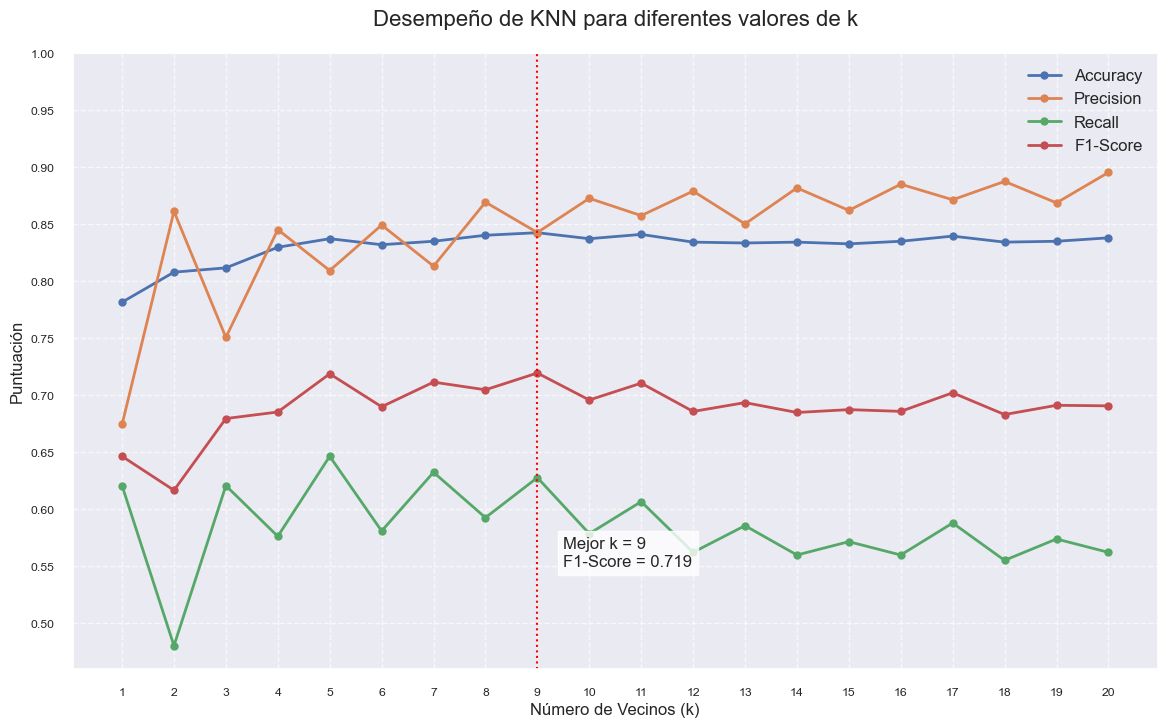


Reporte de Clasificación (k = 9):
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       901
           1       0.84      0.63      0.72       427

    accuracy                           0.84      1328
   macro avg       0.84      0.79      0.81      1328
weighted avg       0.84      0.84      0.84      1328


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       901
           1       0.84      0.63      0.72       427

    accuracy                           0.84      1328
   macro avg       0.84      0.79      0.81      1328
weighted avg       0.84      0.84      0.84      1328



In [276]:
dataset['abandona'] = dataset['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)
print("Columnas disponibles:", dataset.columns.tolist())
variables = [
    'Marital status', 
    'Application mode', 
    'Application order',
    'Course', 
    'Daytime/evening attendance',  # Sin \t
    'Previous qualification',
    'Previous qualification (grade)', 
    'Admission grade', 
    'Age at enrollment',
    'Curricular units 1st sem (credited)', 
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)']
def find_column(possible_names, df_columns):
    for name in possible_names:
        for col in df_columns:
            if name.lower().replace(' ', '') in col.lower().replace(' ', ''):
                return col
    return None
real_columns = []
for var in variables:
    col = find_column([var, var.replace(' ', '_'), var.replace(' ', '')], dataset.columns)
    if col is not None:
        real_columns.append(col)
    else:
        print(f"No se encontró columna para '{var}'")

df = dataset[real_columns].copy()
df.columns = [col.lower().replace(' ', '_').replace('(', '').replace(')', '') for col in df.columns]

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])
X = df  
y = dataset['abandona']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_cols, index=X_test.index)

k_values = range(1, 21)
metrics = {
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for k in k_values:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    
    metrics['Accuracy'].append(accuracy_score(y_test, y_pred))
    metrics['Precision'].append(precision_score(y_test, y_pred))
    metrics['Recall'].append(recall_score(y_test, y_pred))
    metrics['F1-Score'].append(f1_score(y_test, y_pred))

best_k = k_values[np.argmax(metrics['F1-Score'])]
print(f"\nMejor valor de k: {best_k}")

plt.figure(figsize=(14, 8))

for metric_name, values in metrics.items():
    plt.plot(k_values, values, marker='o', label=metric_name, linewidth=2)

plt.title('Desempeño de KNN para diferentes valores de k', fontsize=16, pad=20)
plt.xlabel('Número de Vecinos (k)', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)
plt.xticks(k_values)
plt.yticks(np.arange(0.5, 1.01, 0.05))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

best_score = max(metrics['F1-Score'])
plt.axvline(x=best_k, color='red', linestyle=':', linewidth=1.5)
plt.text(best_k+0.5, 0.55, f'Mejor k = {best_k}\nF1-Score = {best_score:.3f}', 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.show()

final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=best_k))
])
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print("\nReporte de Clasificación (k = {}):".format(best_k))
print(classification_report(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Modelado de Regresión de Calificaciones


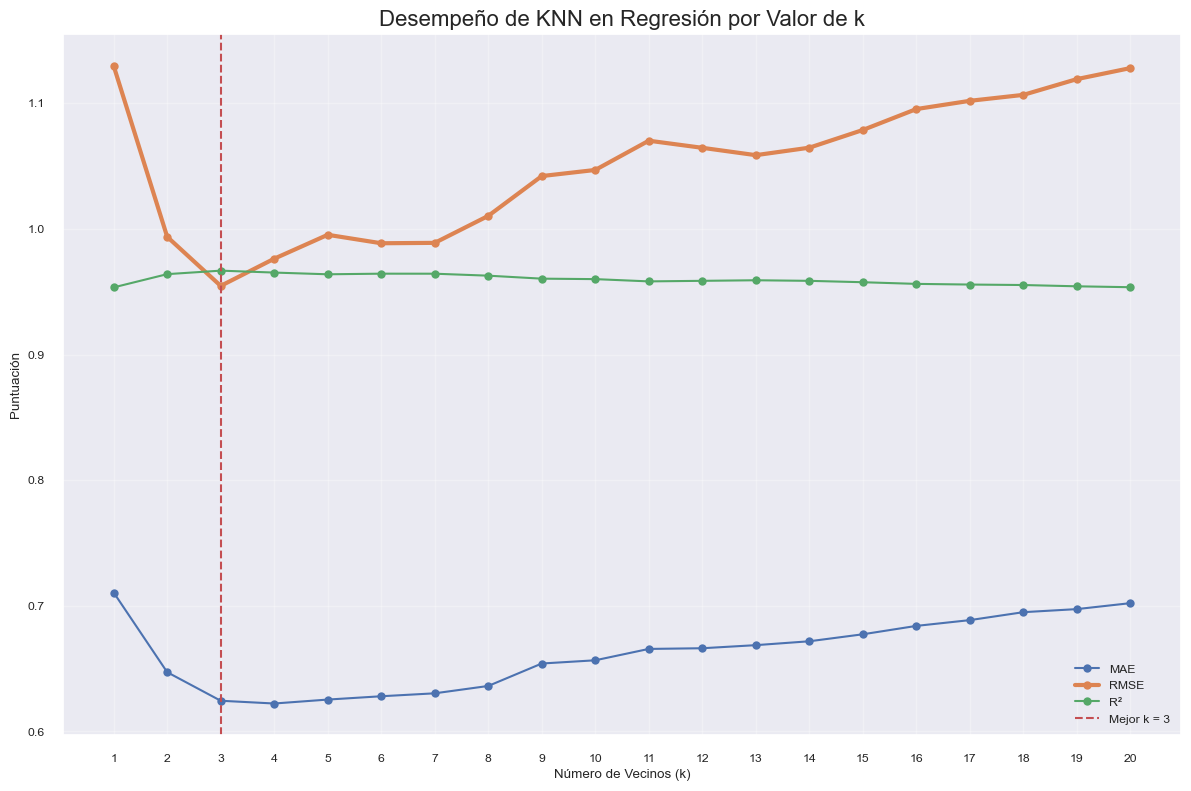


------------------------------------------------------------
Reporte Regresión (k=3)
------------------------------------------------------------
MAE: 0.6245
RMSE: 0.9546
R²: 0.9667
------------------------------------------------------------


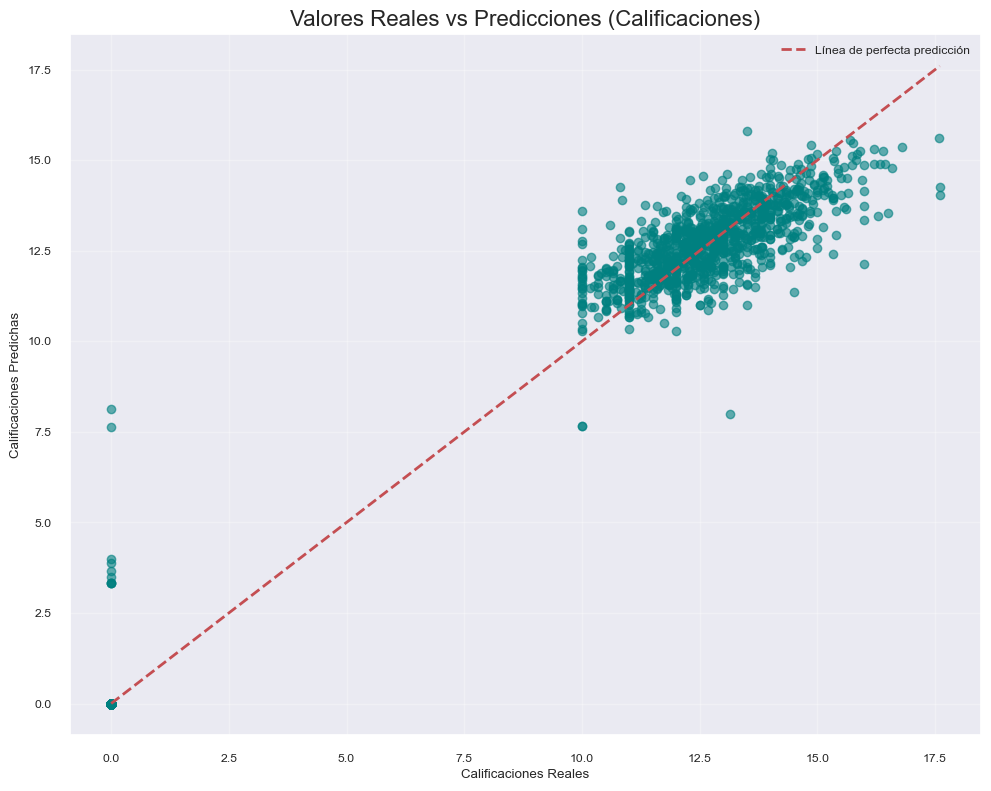

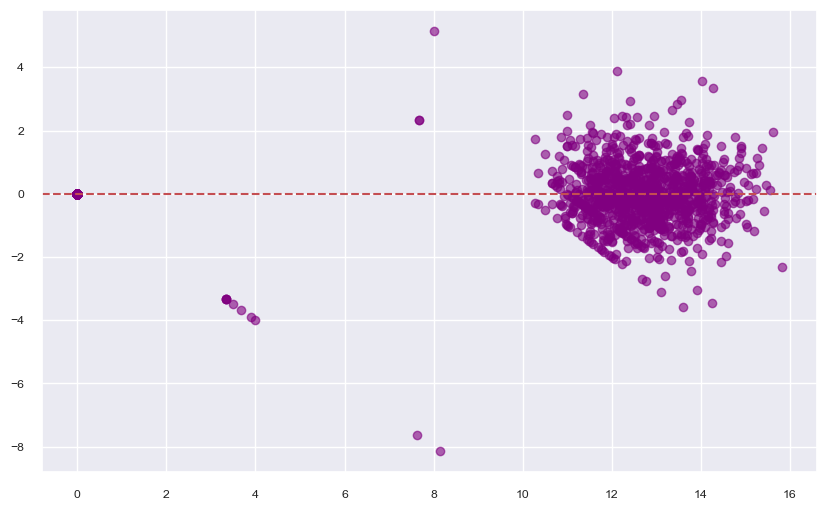

In [277]:
print("Modelado de Regresión de Calificaciones")
calificacion_col = 'Curricular units 2nd sem (grade)'  
if calificacion_col in dataset.columns:
    y_reg = dataset[calificacion_col]
    X_reg = df  
    X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
        X_reg, y_reg, test_size=0.3, random_state=42
    )
    numeric_cols_reg = X_reg_train.select_dtypes(include=['number']).columns.tolist()
    scaler_reg = StandardScaler()
    X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train[numeric_cols_reg])
    X_reg_test_scaled = scaler_reg.transform(X_reg_test[numeric_cols_reg])
    K_LIST = range(1, 21)
    reg_results = []
    
    for k in K_LIST:
        model = KNeighborsRegressor(n_neighbors=k)
        model.fit(X_reg_train_scaled, y_reg_train)
        y_pred = model.predict(X_reg_test_scaled)
        reg_results.append({
            'k': k,
            'mae': mean_absolute_error(y_reg_test, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_reg_test, y_pred)),
            'r2': r2_score(y_reg_test, y_pred)
        })
    
    reg_results_df = pd.DataFrame(reg_results)
    best_k_reg = int(reg_results_df.sort_values('rmse').iloc[0]['k'])
    plt.figure(figsize=(12, 8))
    plt.plot(reg_results_df['k'], reg_results_df['mae'], 'o-', label='MAE')
    plt.plot(reg_results_df['k'], reg_results_df['rmse'], 'o-', label='RMSE', linewidth=3)
    plt.plot(reg_results_df['k'], reg_results_df['r2'], 'o-', label='R²')
    plt.axvline(best_k_reg, color='r', linestyle='--', label=f'Mejor k = {best_k_reg}')
    plt.title('Desempeño de KNN en Regresión por Valor de k', fontsize=16)
    plt.xlabel('Número de Vecinos (k)')
    plt.ylabel('Puntuación')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(K_LIST)
    plt.tight_layout()
    plt.show()
    knn_reg = KNeighborsRegressor(n_neighbors=best_k_reg)
    knn_reg.fit(X_reg_train_scaled, y_reg_train)
    y_reg_pred = knn_reg.predict(X_reg_test_scaled)
    print("\n" + "-"*60)
    print(f"Reporte Regresión (k={best_k_reg})")
    print("-"*60)
    print(f"MAE: {mean_absolute_error(y_reg_test, y_reg_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)):.4f}")
    print(f"R²: {r2_score(y_reg_test, y_reg_pred):.4f}")
    print("-"*60)

    plt.figure(figsize=(10, 8))
    plt.scatter(y_reg_test, y_reg_pred, alpha=0.6, color='teal')
    plt.plot([y_reg_test.min(), y_reg_test.max()], 
             [y_reg_test.min(), y_reg_test.max()], 
             '--r', linewidth=2, label='Línea de perfecta predicción')
    plt.title('Valores Reales vs Predicciones (Calificaciones)', fontsize=16)
    plt.xlabel('Calificaciones Reales')
    plt.ylabel('Calificaciones Predichas')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    residuals = y_reg_test - y_reg_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_reg_pred, residuals, alpha=0.6, color='purple')
    plt.axhline(y=0, color='r', linestyle='--')
else:
    print(f"\nAdvertencia: No se encontró la columna '{calificacion_col}' para regresión")